In [2]:
from pyscf import gto, scf, fci
import netket as nk
import netket.experimental as nkx
import jax.numpy as jnp
from flax import nnx
import jax

# 设置H4分子的几何构型
# 使用线性构型，H-H键长为1.0埃
bond_length = 1.0
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
    ('H', (2*bond_length, 0., 0.)),
    ('H', (3*bond_length, 0., 0.))
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')
mf = scf.RHF(mol).run(verbose=0)

# 进行FCI计算作为参考
E_fci = fci.FCI(mf).kernel()[0]
print(f"FCI能量: {E_fci:.8f} Ha")
ham_nk = nkx.operator.from_pyscf_molecule(mol)
hilbert_space = ham_nk.hilbert

E0 = float(nk.exact.lanczos_ed(ham_nk))
print(f"NetKet精确对角化能量: {E0:.8f} Ha")


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FCI能量: -2.16638745 Ha
NetKet精确对角化能量: -2.16638745 Ha


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_76326/1707035674.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E0 = float(nk.exact.lanczos_ed(ham_nk))


In [6]:
model = nk.models.Slater2nd(hilbert_space, param_dtype=complex)
sampler = nk.sampler.MetropolisLocal(hilbert_space)
# Define an optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)
# Create a variational state
vstate = nk.vqs.MCState(sampler, model, n_samples=2000)
# Create a Variational Monte Carlo driver
preconditioner = nk.optimizer.SR(diag_shift=0.05)
gs = nk.VMC(ham_nk, op, variational_state=vstate, preconditioner=preconditioner)
gs.run(n_iter=300)

  0%|          | 0/300 [00:00<?, ?it/s]/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket

()

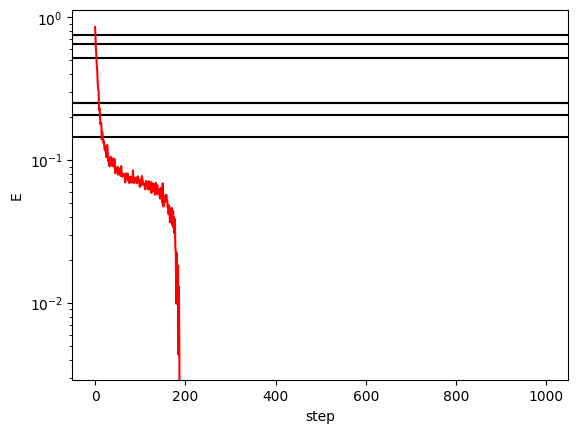

In [13]:
import numpy as np
ed_energies = np.linalg.eigvalsh(ham_nk.to_dense())
import json
import matplotlib.pyplot as plt
exp_name = "H4_log"
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# plot the energy levels
plt.axhline(ed_energies[0], color="red", label="E0")
for e in ed_energies[1:]:
    plt.axhline(e, color="black")
plt.semilogy(x, y - ed_energies[0], color="red", label="VMC")
plt.xlabel("step")
plt.ylabel("E")
plt.show()